# Experiment E00 — Validation Experiment (Dictionary Report, Smoke Test, First Validation)

> **Experiment Specification / Experiment Contract**
>
> This cell is a formal contract describing the entire experiment. It is
> intended to be read by future AI agents that will write the corresponding
> sections of the LaTeX research paper. It documents *what was done → why
> → how → what was measured → what was observed → what evidence supports
> the observations*.

## Experiment Identity

- **Experiment ID:** `E00`
- **Experiment title:** Validation experiment — dictionary report, smoke test, first validation
- **Scientific purpose:** Sanity-check the entire F-SIBS pipeline (datasets →
  dictionaries → algorithms → federated execution → metrics → figures) before
  running the long main sweep (E01) and the ablation experiments (E02, E03).
- **Relationship to the overall paper:** E00 is the *validation* experiment that
  appears in the paper's "Implementation & Validation" subsection. It does not
  itself support a headline scientific claim; instead it establishes that the
  pipeline behaves as expected on a small federated group, and that every
  selected algorithm produces finite SSIM/PSNR/NMSE values at the canonical
  sparsity `k = K_SUMMARY = 8`.
- **Notebook source:** `E00_validation_experiment.ipynb` (F-SIBS Modular project).
- **Run folder:** `F_SIBS_r_<date>_<n>/` (shared with E01/E02/E03 via
  `RUN_DIR_POLICY = "latest"`).
- **Outputs (this enhanced notebook):**
  - `RUN_DIR/figures/exp00_validation_ssim_bar.png`
  - `RUN_DIR/figures/exp00_validation_reconstructions.png`
  - `RUN_DIR/Exp00_Results.tex` (consolidated LaTeX results file)

## Scientific Objective

- **Objective:** Verify, end-to-end, that:
  1. Per-dataset dictionaries have the expected size, coherence, and BPP at
     the canonical sparsity.
  2. A single-node smoke test of every selected single-image method produces
     finite SSIM values on every selected dataset.
  3. On a small federated group, F-SIBS variants produce finite SSIM/PSNR/NMSE
     values, and the *federated* F-SIBS_i improves over its own underlying
     *local* SIBS_i (mean SSIM over the group's nodes).
- **Research question(s):** Does the pipeline produce the expected
  qualitative behaviour (F-SIBS ≥ local SIBS, both ≥ reference codecs at the
  same k) on a small group, before committing to the expensive full sweep?
- **Hypothesis:** F-SIBS_i should match or exceed its underlying local SIBS_i
  on every selected dataset at `k = K_SUMMARY` (the headline federated
  quality-enhancement result, validated here on one group before E01 generalises
  it to all groups).
- **Motivation:** A silent failure in dataset acquisition, dictionary
  construction, or any algorithm wrapper would propagate undetected into E01
  and corrupt the main results; E00 catches such failures cheaply.

## Data

- **Dataset / data source:** Selected from the F-SIBS dataset catalogue:
  `coil20` (COIL-20, 1440 PNG frames, 20 objects), `dino` (Middlebury
  `dinoSparseRing`, 16 PNG frames), `temple` (Middlebury `templeSparseRing`,
  16 PNG frames). Datasets are downloaded / cached automatically by
  `fsibs.datasets.build_data_bundle` under `DATA_DIR`.
- **Dataset characteristics:** grey-scale 8-bit images; `coil20` is
  128 × 128 px, `dino` and `temple` are 96 × 128 px. One *node* = one view
  of one object.
- **Preprocessing:** Grey-scale conversion to 8-bit; per-pool node catalogue
  and federated grouping by dataset-specific adjacency handled by
  `build_data_bundle`.
- **Data partitions:** One validation federated group is selected by
  `_pick_validation_group()` — the first available group whose dataset is in
  the selected pools and that has at least 2 nodes. Default: `coil20_obj01`
  (4 nodes).
- **Relevant assumptions:** Dictionaries are pre-built by `build_data_bundle`;
  the validation group's Φ is the one for the group's dataset; the side image
  for `NDIC-real` is the next view of the same object.

## Methods

- **Proposed methods:** `F-SIBS_1..4` — federated variants paired with
  `SIBS1..SIBS4` via `F_SIBS_VARIANT_TO_SIBS`.
- **Baselines:** `OMP`, `SIBS1..SIBS4`.
- **Reference methods:** `NDIC-equiv s=4/8`, `NDIC-real`, `LDMIC-equiv`,
  `BPG-equiv (JPEG2000)`, `JPEG`, `JPEG-LS`, `SPIHT`, `CALIC`.
- **Method configurations:** Federated variants run with
  `K_global = K_GLOBAL`, `n_rounds = N_ROUNDS_SWEEP`, `tau = 0.95`,
  `eps_conv = EPS_CONV`, `seed = _VAL_SEED = 42`. All single-image methods
  run at `k = K_SUMMARY = 8` and `delta = DELTA`.

## Experimental Design

- **Independent variables:** Dataset, method, federated group.
- **Dependent variables:** SSIM, PSNR (dB), NMSE.
- **Controlled variables:** Sparsity `k = K_SUMMARY = 8`, keyframe spacing
  `delta = DELTA`, dictionary Φ, federated hyper-parameters
  (`K_global`, `n_rounds`, `tau`, `eps_conv`), random seeds `RNG_SEED`
  (global) and `_VAL_SEED = 42` (local).
- **Number of trials / repetitions:** One trial per (method, node); the
  federated run is single-trial with `seed = _VAL_SEED = 42`.
- **Random seeds:** `RNG_SEED` (global) and `_VAL_SEED = 42` (local).

## Evaluation

- **Metrics:** SSIM, PSNR (dB), NMSE, BPP (`bpp_sparse(k, N_atoms, h, w)`).
- **Aggregation:** Mean over the validation group's nodes per (family, method).
- **Statistical analysis:** None in E00 (sanity experiment; E01 has formal tests).

## Outputs

- **Raw experimental results:** `VAL_TABLE` (DataFrame).
- **Processed results:** `VAL_SUMMARY` (DataFrame).
- **Figures (PNG @ 300 DPI, shared `figures/` folder):**
  - `exp00_validation_ssim_bar.png` — mean SSIM bar chart per method.
  - `exp00_validation_reconstructions.png` — reconstruction gallery for node 0.
- **Tables:** `VAL_SUMMARY`, verdict table (F-SIBS_i vs. local SIBS_i).
- **Consolidated LaTeX:** `RUN_DIR/Exp00_Results.tex`.

## Reproducibility

- **Software environment:** Python 3.12.12 (Jupyter Enterprise Gateway kernel
  `jupyter-eg-kernel-slurm-py312-1jo1fcc3c`). Captured at run time by the
  reproducibility cell appended at the end of this notebook.
- **Hardware:** Linux x86_64, 96 CPU cores.
- **`[REQUIRES CONFIRMATION]` items:**
  - `fsibs.protocol.RNG_SEED` (exact integer value; printed at run time).
  - `fsibs.protocol.DELTA` (exact integer value).
  - Exact revision of the Middlebury `dino` / `temple` datasets cached under
    `DATA_DIR` (download timestamp not pinned).


# E00 -- Validation experiment (dictionary report, smoke test, first validation)

Sanity checks of the whole pipeline before any long experiment: per-dataset dictionary report, a one-node smoke test of every selected method at k = K_SUMMARY, and the first validation experiment (federated group, SSIM / reconstruction figures).

* **Independent:** run this notebook top-to-bottom in a fresh kernel; it needs no other notebook's in-memory state.
* **Needs:** datasets (downloaded/cached automatically).
* **Writes:** `fsibs_eval_outputs/` validation figures (the run folder is printed in the setup cell).
* **Shared code:** imported from the `fsibs` package (see `README.md`); everything experiment-specific is in this notebook.

In [10]:
import sys, time, os
from pathlib import Path

# ============================================================
# LOCATE F-SIBS PROJECT
# ============================================================

KNOWN_ROOT = Path("/home/ahmed_omara/F_SIBS_Modular").resolve()
_here = Path.cwd().resolve()

_candidates = [
    KNOWN_ROOT,
    _here,
    *_here.parents,
]

PROJECT_ROOT = next(
    (
        p for p in _candidates
        if (p / "fsibs" / "__init__.py").exists()
    ),
    None,
)


#####################################################################
#Added by me
PROJECT_ROOT = Path("/home/ahmed_omara/F_SIBS_Modular").resolve()
######################################################################
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "\nCould not locate the F-SIBS project.\n"
        "Expected package:\n"
        "  /home/ahmed_omara/F_SIBS_Modular/fsibs/__init__.py\n"
        f"\nCurrent notebook directory:\n  {_here}"
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from fsibs.codecs import run_bpg_equiv
from fsibs.datasets import build_data_bundle
from fsibs.env import setup_environment
from fsibs.federated import (
    F_SIBS_VARIANT_TO_SIBS,
    ldmic_equiv_simulate,
    ndic_equiv,
)
from fsibs.metrics import (
    bpp_sparse,
    dict_coherence,
    nmse,
    psnr,
    ssim,
)
from fsibs.parallel import PBAR_FORMAT, describe
from fsibs.runtime import init_run, new_manifest, save_manifest
from fsibs.selection import prompt_selection, resolve_selection
from fsibs.sparse_coding import omp_baseline

print("All F-SIBS imports completed successfully.")

Project root: /home/ahmed_omara/F_SIBS_Modular
All F-SIBS imports completed successfully.


## Configuration
All settings of this experiment.

In [11]:
# ------------------------------------------------------------------------------------
# EXPERIMENT CONFIGURATION -- everything that can differ between experiments lives HERE,
# in this notebook.  Edit freely; no other notebook or module is affected.
# ------------------------------------------------------------------------------------
RUN_DIR_POLICY = "latest"      # "latest": re-use the newest F_SIBS_r_<date>_<n> folder (shared with the other
                               #   notebooks) | "new": start a fresh run folder | or an explicit folder path
INTERACTIVE_SELECTION = False  # True: ask for datasets / algorithms with the original input() menus

# Datasets: any of "coil20", "coil100", "eth80", "epfl", "dino", "temple"
SELECTED_DATASETS = ["coil20", "dino", "temple"]
# Algorithms: SIBSk and F-SIBS_k must be selected together (pairing rule); all other baselines are free
SELECTED_ALGORITHMS = [
    "OMP",
    "SIBS1",
    "F-SIBS_1",
    "SIBS2",
    "F-SIBS_2",
    "SIBS3",
    "F-SIBS_3",
    "SIBS4",
    "F-SIBS_4",
    "NDIC-equiv s=4",
    "NDIC-equiv s=8",
    "NDIC-real",
    "LDMIC-equiv",
    "BPG-equiv (JPEG2000)",
    "JPEG",
    "JPEG-LS",
    "SPIHT",
    "CALIC",
]

# ---- shared evaluation-protocol values (defaults from fsibs.protocol; override here for THIS experiment only) ----
from fsibs import protocol as P
RNG_SEED = P.RNG_SEED
COIL_VIEWS = P.COIL_VIEWS
COIL100_VIEWS = P.COIL100_VIEWS
ETH80_VIEWS = P.ETH80_VIEWS
COIL100_MAX_OBJECTS = P.COIL100_MAX_OBJECTS
ETH80_MAX_OBJECTS_PER_CAT = P.ETH80_MAX_OBJECTS_PER_CAT
EPFL_MAX_FRAMES = P.EPFL_MAX_FRAMES
EPFL_TARGET_HW = P.EPFL_TARGET_HW
COIL_N_CROSS_GROUPS = P.COIL_N_CROSS_GROUPS
K_SUMMARY = P.K_SUMMARY
GEOMETRY = P.GEOMETRY
DELTA = P.DELTA
K_GLOBAL = P.K_GLOBAL
N_ROUNDS_SWEEP = P.N_ROUNDS_SWEEP
EPS_CONV = P.EPS_CONV

## Setup
Run folder, selection and (when needed) datasets.

In [12]:
setup_environment(RNG_SEED)                       # warnings, global seed, Matplotlib defaults
describe()                                       # CPU / platform banner
run = init_run(RUN_DIR_POLICY)                    # resolves F_SIBS_r_<date>_<n> and creates its folders
RUN_DIR, FIG_DIR, RESULTS_DIR, DATA_DIR = run.RUN_DIR, run.FIG_DIR, run.RESULTS_DIR, run.DATA_DIR
EXPERIMENT_MANIFEST = new_manifest()              # files this notebook registers as outputs
print("RUN_DIR     :", RUN_DIR)
print("DATA_DIR    :", DATA_DIR)

# ---- algorithm / dataset selection (enforces the SIBSk <-> F-SIBS_k pairing rule) ----
if INTERACTIVE_SELECTION:
    SELECTED_DATASETS, SELECTED_ALGORITHMS = prompt_selection()
sel = resolve_selection(SELECTED_DATASETS, SELECTED_ALGORITHMS)
SELECTED_DATASETS, SELECTED_ALGORITHMS = sel.SELECTED_DATASETS, sel.SELECTED_ALGORITHMS
SELECTED_BASELINES = sel.SELECTED_BASELINES
SELECTED_SIBS_VARIANTS = sel.SELECTED_SIBS_VARIANTS
SELECTED_DATASETS_SET = sel.SELECTED_DATASETS_SET
SELECTED_METHODS_SET = sel.SELECTED_METHODS_SET
ACTIVE_SIBS_METHODS = sel.ACTIVE_SIBS_METHODS
ACTIVE_F_SIBS_VARIANTS = sel.ACTIVE_F_SIBS_VARIANTS

# ---- datasets: acquisition (cached in DATA_DIR), node pools, federated groups ----
data = build_data_bundle(
    SELECTED_DATASETS, DATA_DIR,
    coil_views=COIL_VIEWS, coil100_views=COIL100_VIEWS, eth80_views=ETH80_VIEWS,
    coil100_max_objects=COIL100_MAX_OBJECTS, eth80_max_objects_per_cat=ETH80_MAX_OBJECTS_PER_CAT,
    epfl_max_frames=EPFL_MAX_FRAMES, epfl_target_hw=EPFL_TARGET_HW,
    coil_n_cross_groups=COIL_N_CROSS_GROUPS)
POOLS, PHI, GROUPS = data.POOLS, data.PHI, data.GROUPS

effective_cpu_count() = 96 | platform = Linux | MULTIPROCESSING_AVAILABLE = True
RUN_DIR     : /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-27_1
DATA_DIR    : /home/ahmed_omara/F_SIBS_Modular/fsibs_data
EXPERIMENT CONFIGURATION

Selected datasets:
    COIL-20
    Middlebury Dino
    Middlebury Temple

Selected SIBS <-> F-SIBS pairs:
    SIBS1  + F-SIBS_1 
    SIBS2  + F-SIBS_2 
    SIBS3  + F-SIBS_3 
    SIBS4  + F-SIBS_4 

Selected other baselines:
    OMP
    NDIC-equiv s=4
    NDIC-equiv s=8
    NDIC-real
    LDMIC-equiv
    BPG-equiv (JPEG2000)
    JPEG
    JPEG-LS
    SPIHT
    CALIC

Final algorithms (SELECTED_METHODS):
    OMP
    SIBS1
    F-SIBS_1
    SIBS2
    F-SIBS_2
    SIBS3
    F-SIBS_3
    SIBS4
    F-SIBS_4
    NDIC-equiv s=4
    NDIC-equiv s=8
    NDIC-real
    LDMIC-equiv
    BPG-equiv (JPEG2000)
    JPEG
    JPEG-LS
    SPIHT
    CALIC
Configuration valid -- proceeding with the experiment campaign.
Active local SIBS methods (from SELECTED_BASELINES / SELECTED_S

Middlebury datasets: 100% complete |██████████| 2/2 [00:00<00:00]


COIL-20 images: 1440 files in /home/ahmed_omara/F_SIBS_Modular/fsibs_data/Image_Classfiation_Coil20-master/dataset
dino    images: 16 PNGs in /home/ahmed_omara/F_SIBS_Modular/fsibs_data/dinoSparseRing
temple  images: 16 PNGs in /home/ahmed_omara/F_SIBS_Modular/fsibs_data/templeSparseRing
COIL-100: not selected -> acquisition skipped
ETH-80: not selected -> acquisition skipped
EPFL: not selected -> acquisition skipped


COIL-20 objects: 100% complete |██████████| 20/20 [00:00<00:00]
dino frames: 100% complete |██████████| 16/16 [00:00<00:00]
temple frames: 100% complete |██████████| 16/16 [00:00<00:00]

Node catalogue (one view of one object per node):
dataset  nodes  subjects  img_shape
 coil20     80        20 (128, 128)
   dino     16         1  (96, 128)
 temple     16         1  (96, 128)

federated node groups:
  coil20_same_object      20 groups | 4 members each
  coil20_cross_object      5 groups | 4 members each
  dino_ring                1 groups | 16 members each
  temple_ring              1 groups | 16 members each

NODE_CATALOG built: 112 rows across 3 datasets


## Experiment-specific helpers
Defined here (not in `fsibs`) because no other experiment uses them.

In [13]:
def _pick_validation_group():
    _prefix_dataset = {"coil20_same_object": "coil20",
                       "coil100_same_object": "coil100",
                       "eth80_same_category": "eth80",
                       "dino_ring": "dino", "temple_ring": "temple"}
    preferred_prefixes = tuple(
        p for p in ("coil20_same_object", "coil100_same_object",
                    "eth80_same_category", "dino_ring", "temple_ring")
        if _prefix_dataset[p] in SELECTED_DATASETS_SET)
    for pref in preferred_prefixes:
        if pref in GROUPS and GROUPS[pref]:
            g = GROUPS[pref][0]
            if g["dataset"] in POOLS and len(g["node_idx"]) >= 2:
                return g
    for cfg, groups in GROUPS.items():
        for g in groups:
            if g["dataset"] in POOLS and len(g["node_idx"]) >= 2:
                return g
    raise RuntimeError("No usable federated group found -- check dataset acquisition (Cell 5).")

## Experiment

dictionaries: 100% complete |██████████| 3/3 [00:00<00:00]


coil20  dictionary: 128 atoms | coherence mu = 0.0000 | bpp @ k=8: 1.438
dino    dictionary: 96 atoms | coherence mu = 0.0000 | bpp @ k=8: 1.917
temple  dictionary: 96 atoms | coherence mu = 0.0000 | bpp @ k=8: 1.917

smoke test (first node of each pool, k=8):


smoke test:  33% complete |███▎      | 1/3 [00:00<00:00]

  coil20  coil20:obj01@000deg      OMP SSIM=0.6626 | SIBS1 SSIM=0.8051 | NDIC-real SSIM=0.3732


smoke test:  67% complete |██████▋   | 2/3 [00:00<00:00]

  dino    dino:cam01               OMP SSIM=0.6925 | SIBS1 SSIM=0.7419 | NDIC-real SSIM=0.5032


smoke test: 100% complete |██████████| 3/3 [00:00<00:00]

  temple  temple:cam01             OMP SSIM=0.6444 | SIBS1 SSIM=0.7119 | NDIC-real SSIM=0.5621
smoke test done in 0.5s
First validation experiment -- group: coil20_obj01 (coil20), 4 node(s): ['coil20:obj01@000deg', 'coil20:obj01@090deg', 'coil20:obj01@180deg', 'coil20:obj01@270deg']



First validation experiment -- comparison table (mean over 4 node(s)):
                family               method   SSIM    PSNR   NMSE
baseline (independent)                  OMP 0.6921 24.0721 0.0140
baseline (independent)                SIBS1 0.8149 28.3319 0.0052
baseline (independent)                SIBS2 0.8366 28.9990 0.0045
baseline (independent)                SIBS3 0.8380 29.1003 0.0044
baseline (independent)                SIBS4 0.8173 28.3379 0.0052
    F-SIBS (federated)             F-SIBS_1 0.8388 29.5670 0.0039
    F-SIBS (federated)             F-SIBS_2 0.8619 30.3235 0.0033
    F-SIBS (federated)             F-SIBS_3 0.8627 30.3903 0.0032
    F-SIBS (federated)             F-SIBS_4 0.8343 29.3787 0.0041
reference (multi-view)          LDMIC-equiv 0.6260 19.1573 0.0456
 reference (side-info)            NDIC-real 0.3732  9.4926 0.4247
     reference (codec) BPG-equiv (JPEG2000) 0.9943 45.8500 0.0001

Verdict (F-SIBS_i vs. its own underlying local SIBS_i, mean SSIM):
  

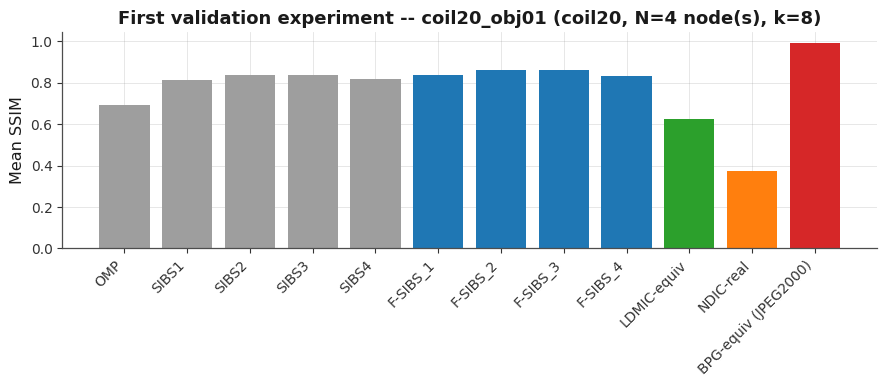

saved: /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-27_1/fsibs_eval_outputs/validation_experiment_ssim.png


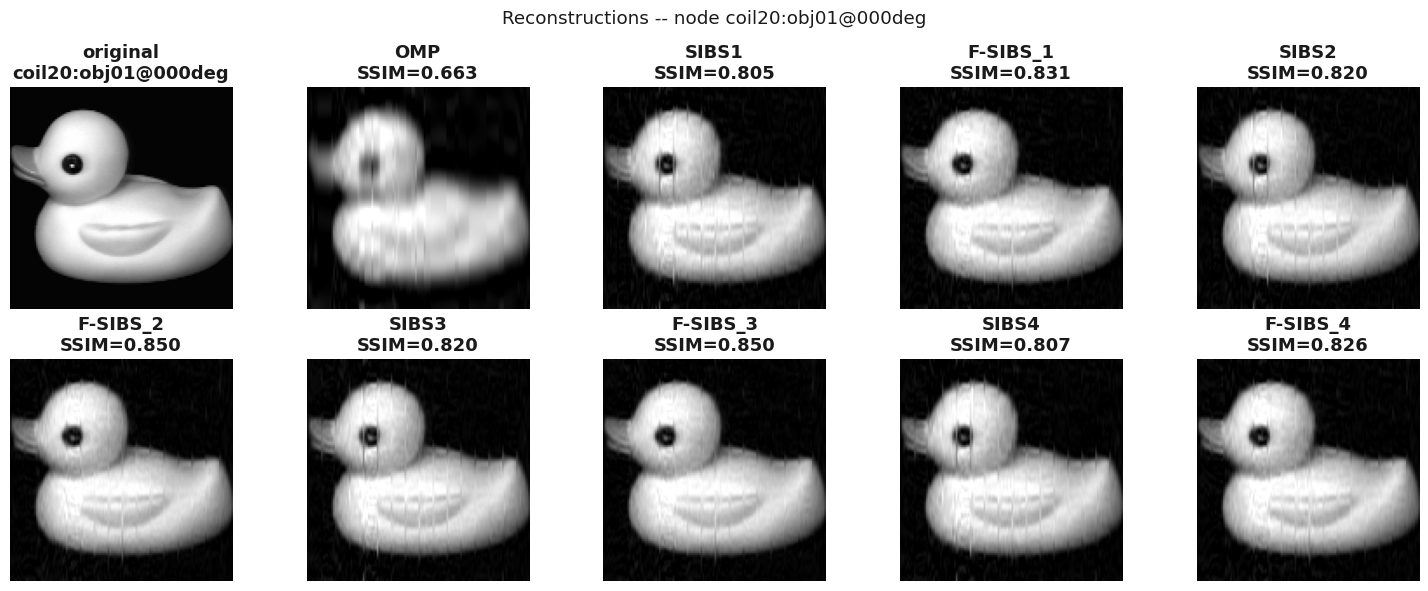

saved: /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-27_1/fsibs_eval_outputs/validation_experiment_reconstructions.png

First validation experiment complete: 42 rows in VAL_TABLE, 12 methods compared.
Proceed to Section 4 (main evaluation sweep) only after reviewing the table/figures above.


In [14]:
# ---- per-dataset dictionary report + smoke test (original Cell 10;
#      the duplicate PHI rebuild was removed -- PHI above is identical) ----

for ds, Phi in tqdm(PHI.items(), desc="dictionaries", bar_format=PBAR_FORMAT):
    h, w = GEOMETRY[ds]
    print("%-7s dictionary: %2d atoms | coherence mu = %.4f | bpp @ k=8: %.3f"
          % (ds, Phi.shape[1], dict_coherence(Phi), bpp_sparse(8, Phi.shape[1], h, w)))

# ---- smoke test (first node of each pool, k=8) --------------------------
# CENTRAL SELECTION: the smoke test exercises only SELECTED single-image
# methods -- OMP whenever selected, the first active local SIBS variant
# stands in for the SIBS family, and NDIC-real only when selected.
_smoke_single = []
if "OMP" in SELECTED_METHODS_SET:
    _smoke_single.append(("OMP", omp_baseline))
if ACTIVE_SIBS_METHODS:
    _sm_sibs_name, _sm_sibs_fn = next(iter(ACTIVE_SIBS_METHODS.items()))
    _smoke_single.append((_sm_sibs_name, _sm_sibs_fn))

t0 = time.time()
print("\nsmoke test (first node of each pool, k=8):")
for ds in tqdm(POOLS, desc="smoke test", bar_format=PBAR_FORMAT):
    pool = POOLS[ds]; Phi = PHI[ds]
    nd = pool[0]; X = nd["img"]; X_side = pool[nd["side_idx"]]["img"]
    _parts = []
    for _mname, _mfn in _smoke_single:
        Xh_m = np.clip(_mfn(X, Phi, DELTA, 8), 0, 255)
        _parts.append("%s SSIM=%.4f" % (_mname, ssim(X, Xh_m)))
    if "NDIC-real" in SELECTED_METHODS_SET:
        Xh_ndic = ndic_equiv(X, X_side, Phi, DELTA, 8)
        _parts.append("NDIC-real SSIM=%.4f" % ssim(X, Xh_ndic))
    print("  %-7s %-24s %s" % (ds, nd["node_id"],
                               " | ".join(_parts) if _parts
                               else "(no single-image method selected -> skipped)"))
print("smoke test done in %.1fs" % (time.time() - t0))

# ---- FIRST VALIDATION EXPERIMENT (original Cell 8c, verbatim;
#      _pick_validation_group lives in Cell 2 Section 2.9) ----

_VAL_K = K_SUMMARY          # same sparsity as the rest of the notebook (k=8)
_VAL_SEED = 42

_val_group = _pick_validation_group()
_val_ds = _val_group["dataset"]
_val_Phi = PHI[_val_ds]
_val_imgs = [POOLS[_val_ds][i]["img"] for i in _val_group["node_idx"]]
_val_node_ids = [POOLS[_val_ds][i]["node_id"] for i in _val_group["node_idx"]]
print("First validation experiment -- group: %s (%s), %d node(s): %s"
      % (_val_group["group_id"], _val_ds, len(_val_imgs), _val_node_ids))

# ---- 1. independent (non-federated) baselines, identical conditions -----
# CENTRAL SELECTION: OMP when selected + the active local SIBS methods
# (SELECTED_BASELINES u SELECTED_SIBS_VARIANTS, order-preserving).
_BASELINE_FNS = {}
if "OMP" in SELECTED_METHODS_SET:
    _BASELINE_FNS["OMP"] = omp_baseline
_BASELINE_FNS.update(ACTIVE_SIBS_METHODS)
_val_rows = []
_val_recons = {}   # method -> list of reconstructions, one per node (node 0 used for figures)

for name, fn in _BASELINE_FNS.items():
    recons = [np.clip(fn(X, _val_Phi, DELTA, _VAL_K), 0, 255) for X in _val_imgs]
    _val_recons[name] = recons
    for nid, X, Xh in zip(_val_node_ids, _val_imgs, recons):
        _val_rows.append({"method": name, "family": "baseline (independent)",
                          "node_id": nid, "SSIM": ssim(X, Xh), "PSNR": psnr(X, Xh),
                          "NMSE": nmse(X, Xh)})

# ---- 2. federated F-SIBS variants (automatically selected), identical ---
#      conditions ----------------------------------------------------------
for vname, vfn in ACTIVE_F_SIBS_VARIANTS.items():
    res = vfn(_val_imgs, _val_Phi, DELTA, _VAL_K, K_global=K_GLOBAL,
              n_rounds=N_ROUNDS_SWEEP, tau=0.95, eps_conv=EPS_CONV, seed=_VAL_SEED)
    recons = [np.clip(Xh, 0, 255) for Xh in res["reconstructions_all"]]
    _val_recons[vname] = recons
    for nid, X, Xh in zip(_val_node_ids, _val_imgs, recons):
        _val_rows.append({"method": vname, "family": "F-SIBS (federated)",
                          "node_id": nid, "SSIM": ssim(X, Xh), "PSNR": psnr(X, Xh),
                          "NMSE": nmse(X, Xh)})

# ---- 3. LDMIC-equiv reference (multi-view, no federation rounds) --------
if "LDMIC-equiv" in SELECTED_METHODS_SET and len(_val_imgs) >= 2:
    ldmic_recons = [np.clip(Xh, 0, 255) for Xh in
                    ldmic_equiv_simulate(_val_imgs, _val_Phi, DELTA, _VAL_K)]
    _val_recons["LDMIC-equiv"] = ldmic_recons
    for nid, X, Xh in zip(_val_node_ids, _val_imgs, ldmic_recons):
        _val_rows.append({"method": "LDMIC-equiv", "family": "reference (multi-view)",
                          "node_id": nid, "SSIM": ssim(X, Xh), "PSNR": psnr(X, Xh),
                          "NMSE": nmse(X, Xh)})
elif "LDMIC-equiv" in SELECTED_METHODS_SET:
    print("LDMIC-equiv reference row skipped: the validation group has < 2 nodes.")

# ---- 4. NDIC-real + BPG-equiv reference, first node only -----------------
if "NDIC-real" in SELECTED_METHODS_SET:
    _val_first_idx = _val_group["node_idx"][0]
    _val_X0 = POOLS[_val_ds][_val_first_idx]["img"]
    _val_side0 = POOLS[_val_ds][POOLS[_val_ds][_val_first_idx]["side_idx"]]["img"]
    _ndic_recon0 = ndic_equiv(_val_X0, _val_side0, _val_Phi, DELTA, _VAL_K)
    _val_rows.append({"method": "NDIC-real", "family": "reference (side-info)",
                      "node_id": _val_node_ids[0], "SSIM": ssim(_val_X0, _ndic_recon0),
                      "PSNR": psnr(_val_X0, _ndic_recon0), "NMSE": nmse(_val_X0, _ndic_recon0)})
if "BPG-equiv (JPEG2000)" in SELECTED_METHODS_SET:
    _val_first_idx = _val_group["node_idx"][0]
    _val_X0 = POOLS[_val_ds][_val_first_idx]["img"]
    _bpg_out = run_bpg_equiv(_val_X0, rates=[K_SUMMARY])
    _val_rows.append({"method": "BPG-equiv (JPEG2000)", "family": "reference (codec)",
                      "node_id": _val_node_ids[0], "SSIM": _bpg_out[0]["SSIM"],
                      "PSNR": _bpg_out[0]["PSNR"], "NMSE": _bpg_out[0]["NMSE"]})

VAL_TABLE = pd.DataFrame(_val_rows)
VAL_SUMMARY = (VAL_TABLE.groupby(["family", "method"], sort=False)[["SSIM", "PSNR", "NMSE"]]
              .mean().round(4).reset_index())
print("\nFirst validation experiment -- comparison table (mean over %d node(s)):"
      % len(_val_imgs))
print(VAL_SUMMARY.to_string(index=False))

# ---- 5. verdict: does each F-SIBS_i improve on its own local SIBS_i? -----
# (only for the automatically selected F-SIBS variants)
print("\nVerdict (F-SIBS_i vs. its own underlying local SIBS_i, mean SSIM):")
for vname, sibs_name in F_SIBS_VARIANT_TO_SIBS.items():
    if vname not in ACTIVE_F_SIBS_VARIANTS:
        continue   # variant not selected in this run
    ssim_fed = VAL_SUMMARY.loc[VAL_SUMMARY.method == vname, "SSIM"]
    ssim_loc = VAL_SUMMARY.loc[VAL_SUMMARY.method == sibs_name, "SSIM"]
    if len(ssim_fed) and len(ssim_loc):
        d = float(ssim_fed.iloc[0] - ssim_loc.iloc[0])
        verdict = "IMPROVES over" if d > 0 else ("MATCHES" if abs(d) < 1e-9 else "UNDERPERFORMS")
        print("  %-9s (local %-5s SSIM=%.4f) -> %-9s SSIM=%.4f  [%s local %s by %+.4f]"
              % (sibs_name, sibs_name, ssim_loc.iloc[0], vname, ssim_fed.iloc[0],
                 verdict, sibs_name, d))
    elif len(ssim_fed):
        print("  %-9s -> %-9s verdict skipped (local %s was not selected)"
              % (sibs_name, vname, sibs_name))

# ---- 6. figure: mean SSIM bar chart --------------------------------------
_fig, _ax = plt.subplots(figsize=(9, 4))
_colors = {"baseline (independent)": "#9e9e9e", "F-SIBS (federated)": "#1f77b4",
          "reference (multi-view)": "#2ca02c", "reference (side-info)": "#ff7f0e",
          "reference (codec)": "#d62728"}
_bar_colors = [_colors.get(f, "#555555") for f in VAL_SUMMARY["family"]]
_ax.bar(VAL_SUMMARY["method"], VAL_SUMMARY["SSIM"], color=_bar_colors)
_ax.set_ylabel("Mean SSIM"); _ax.set_title(
    "First validation experiment -- %s (%s, N=%d node(s), k=%d)"
    % (_val_group["group_id"], _val_ds, len(_val_imgs), _VAL_K))
_ax.tick_params(axis="x", rotation=45)
for lbl in _ax.get_xticklabels(): lbl.set_ha("right")
plt.tight_layout()
_val_fig_path = os.path.join(FIG_DIR, "validation_experiment_ssim.png")
plt.savefig(_val_fig_path); plt.show()
print("saved:", _val_fig_path)

# ---- 7. figure: reconstructed images for node 0 --------------------------
_val_methods_for_grid = ["OMP", "SIBS1", "F-SIBS_1", "SIBS2", "F-SIBS_2",
                         "SIBS3", "F-SIBS_3", "SIBS4", "F-SIBS_4"]
_val_methods_for_grid = [m for m in _val_methods_for_grid if m in _val_recons]
_n_show = 1 + len(_val_methods_for_grid)
_ncols = min(5, _n_show); _nrows = int(np.ceil(_n_show / _ncols))
_fig2, _axes = plt.subplots(_nrows, _ncols, figsize=(3 * _ncols, 3 * _nrows))
_axes = np.atleast_1d(_axes).ravel()
_axes[0].imshow(_val_imgs[0], cmap="gray", vmin=0, vmax=255)
_axes[0].set_title("original\n%s" % _val_node_ids[0]); _axes[0].axis("off")
for _j, _m in enumerate(_val_methods_for_grid, start=1):
    _axes[_j].imshow(_val_recons[_m][0], cmap="gray", vmin=0, vmax=255)
    _axes[_j].set_title("%s\nSSIM=%.3f" % (_m, ssim(_val_imgs[0], _val_recons[_m][0])))
    _axes[_j].axis("off")
for _j in range(_n_show, len(_axes)):
    _axes[_j].axis("off")
plt.suptitle("Reconstructions -- node %s" % _val_node_ids[0])
plt.tight_layout()
_val_fig2_path = os.path.join(FIG_DIR, "validation_experiment_reconstructions.png")
plt.savefig(_val_fig2_path); plt.show()
print("saved:", _val_fig2_path)

print("\nFirst validation experiment complete: %d rows in VAL_TABLE, %d methods compared."
      % (len(VAL_TABLE), VAL_TABLE.method.nunique()))
print("Proceed to Section 4 (main evaluation sweep) only after reviewing the table/figures above.")


# ## Experiment E1 — Federated Quality Gain at Fixed k
# 
# **Objective.** Prove F-SIBS beats local SIBS and independent OMP at fixed sparsity k
# (headline federated quality-enhancement result).
# 
# **Inputs:** `POOLS`/`PHI`/`GROUPS` (Cell 3), selection (Cell 1), algorithm functions
# (Cell 2). **Outputs:** `RESULTS` tidy table + fingerprinted CSV cache;
# summary table at k=`K_SUMMARY`; paired t-test table (F-SIBS vs. every baseline, per-node
# pairs) **with Holm-Bonferroni & Benjamini-Hochberg adjusted p-values and Cohen's d /
# Hedges' g effect sizes** (V3.2 addition).
# 
# **Figures:** R-D curves (SSIM & PSNR vs. BPP), bar charts at k=`K_SUMMARY`, paired-gain
# beeswarm with mean±95% CI, per-node SSIM ECDF, gain-vs-difficulty scatter, reconstruction
# gallery. **Tables:** `fsibs_full_results_v2__*.csv`, `fsibs_summary_k8.csv`,
# `stat_main_sweep.csv`. **Contribution supported:** headline result (federation improves
# reconstruction quality at equal k).

In [15]:
# ============================================================
# ENHANCEMENT HELPERS -- shared inline setup cell.
# Implements the "Generate -> Save PNG -> Display inline -> Register
# -> Add to .tex" workflow. All figures are saved as PNG @ 300 DPI to a
# single shared RUN_DIR/figures/ directory (no experiment-specific
# subfolders). The .tex file lives at RUN_DIR/Exp0X_Results.tex.
# ============================================================
import os, sys, json, time, platform
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

# ---- Resolve the shared figures directory and the consolidated .tex ----
# RUN_DIR is set by the original notebook's setup cell. The shared
# figures/ folder lives directly under RUN_DIR (NOT under FIG_DIR, so
# all experiments share one folder). The .tex file also lives directly
# under RUN_DIR.
_RUN_DIR = Path(globals().get("RUN_DIR", ".")).resolve()
SHARED_FIG_DIR = _RUN_DIR / "figures"
SHARED_FIG_DIR.mkdir(parents=True, exist_ok=True)

def _escape_latex(s):
    """Escape LaTeX special characters in a string for safe inclusion in
    table cells and captions."""
    if s is None:
        return ""
    s = str(s)
    for ch, repl in [("\\", r"\textbackslash{}"), ("&", r"\&"),
                     ("%", r"\%"), ("$", r"\$"), ("#", r"\#"),
                     ("_", r"\_"), ("{", r"\{"), ("}", r"\}"),
                     ("~", r"\textasciitilde{}"), ("^", r"\textasciicircum{}")]:
        s = s.replace(ch, repl)
    return s

def _fmt_num(v, nd=4):
    """Format a numeric value for LaTeX, handling NaN gracefully."""
    if v is None:
        return "---"
    try:
        f = float(v)
    except (TypeError, ValueError):
        return _escape_latex(v)
    if not np.isfinite(f):
        return "---"
    if isinstance(v, (int, np.integer)) and float(v) == f:
        return str(int(v))
    return f"{f:.{nd}f}"

# ---- State: the consolidated .tex file path and the open buffer -------
_EXPERIMENT_TEX_PATH = None      # set by init_experiment_tex
_EXPERIMENT_TEX_LINES = []       # list of str lines accumulated so far
_FIGURE_REGISTRY = {}            # id -> {filename, label, caption, purpose, ...}
_TABLE_REGISTRY = {}              # id -> {label, caption, purpose, ...}

def init_experiment_tex(experiment_id, title, intro_latex, notebook_filename):
    """Initialize (or reset) the consolidated experiment .tex file.

    Saves the path and writes the file header + intro to the in-memory
    buffer. The file is written to disk by finalize_experiment_tex()
    OR by save_experiment_tex_now() (which can be called between cells
    to flush a partial file)."""
    global _EXPERIMENT_TEX_PATH, _EXPERIMENT_TEX_LINES
    _EXPERIMENT_TEX_PATH = _RUN_DIR / f"Exp{experiment_id}_Results.tex"
    _EXPERIMENT_TEX_LINES = []
    _EXPERIMENT_TEX_LINES.append(r"% ============================================================================")
    _EXPERIMENT_TEX_LINES.append(r"% Exp" + str(experiment_id) + r"_Results.tex")
    _EXPERIMENT_TEX_LINES.append(r"% Consolidated LaTeX results file for Experiment " + str(experiment_id) + ".")
    _EXPERIMENT_TEX_LINES.append(r"% AUTO-GENERATED BY " + str(notebook_filename) + ".")
    _EXPERIMENT_TEX_LINES.append(r"% Numerical values come from the live in-memory DataFrames.")
    _EXPERIMENT_TEX_LINES.append(r"% Do not edit by hand; re-run the notebook to regenerate.")
    _EXPERIMENT_TEX_LINES.append(r"% Figures are PNG @ 300 DPI, saved to the shared RUN_DIR/figures/ folder.")
    _EXPERIMENT_TEX_LINES.append(r"% ============================================================================")
    _EXPERIMENT_TEX_LINES.append("")
    _EXPERIMENT_TEX_LINES.append(r"% --- Experiment " + str(experiment_id) + " introduction ---")
    _EXPERIMENT_TEX_LINES.append(r"\section*{" + _escape_latex(title) + "}")
    _EXPERIMENT_TEX_LINES.append("")
    if intro_latex:
        _EXPERIMENT_TEX_LINES.append(intro_latex.strip("\n"))
        _EXPERIMENT_TEX_LINES.append("")
    print(f"Initialized: {_EXPERIMENT_TEX_PATH}")
    print(f"Shared figures directory: {SHARED_FIG_DIR}")
    save_experiment_tex_now()
    return _EXPERIMENT_TEX_PATH

def save_experiment_tex_now():
    """Flush the current in-memory .tex buffer to disk."""
    if _EXPERIMENT_TEX_PATH is None:
        return None
    with open(_EXPERIMENT_TEX_PATH, "w") as f:
        f.write("\n".join(_EXPERIMENT_TEX_LINES) + "\n")
    return _EXPERIMENT_TEX_PATH

def finalize_experiment_tex(experiment_id, observations_latex=None,
                            reproducibility_dict=None):
    """Append observations, figure/table registry, and reproducibility
    metadata as LaTeX comments, then flush to disk."""
    if observations_latex:
        _EXPERIMENT_TEX_LINES.append(r"% --- Scientific observations ---")
        _EXPERIMENT_TEX_LINES.append(observations_latex.strip("\n"))
        _EXPERIMENT_TEX_LINES.append("")
    _EXPERIMENT_TEX_LINES.append(r"% ===========================================================================")
    _EXPERIMENT_TEX_LINES.append(r"% Figure & Table Registry (machine-readable, for AI paper-writing agents)")
    _EXPERIMENT_TEX_LINES.append(r"% ===========================================================================")
    _EXPERIMENT_TEX_LINES.append(r"% Figures:")
    for fig_id, info in _FIGURE_REGISTRY.items():
        _EXPERIMENT_TEX_LINES.append(
            r"% " + fig_id + " | file: " + info["filename"]
            + r" | label: " + info["label"])
        _EXPERIMENT_TEX_LINES.append(r"%   purpose: " + info.get("purpose", ""))
        _EXPERIMENT_TEX_LINES.append(
            r"%   dataset: " + info.get("dataset", "")
            + r" | methods: " + info.get("methods", "")
            + r" | metric: " + info.get("metrics", ""))
        _EXPERIMENT_TEX_LINES.append(
            r"%   finding: " + info.get("scientific_finding", ""))
    _EXPERIMENT_TEX_LINES.append(r"% Tables:")
    for tbl_id, info in _TABLE_REGISTRY.items():
        _EXPERIMENT_TEX_LINES.append(
            r"% " + tbl_id + r" | label: " + info["label"])
        _EXPERIMENT_TEX_LINES.append(r"%   purpose: " + info.get("purpose", ""))
        _EXPERIMENT_TEX_LINES.append(
            r"%   dataset: " + info.get("dataset", "")
            + r" | methods: " + info.get("methods", "")
            + r" | metrics: " + info.get("metrics", ""))
    if reproducibility_dict:
        _EXPERIMENT_TEX_LINES.append(r"% ===========================================================================")
        _EXPERIMENT_TEX_LINES.append(r"% Reproducibility metadata")
        _EXPERIMENT_TEX_LINES.append(r"% ===========================================================================")
        for k, v in reproducibility_dict.items():
            if isinstance(v, (dict, list)):
                _EXPERIMENT_TEX_LINES.append(r"% " + k + ": " + json.dumps(v, default=str))
            else:
                _EXPERIMENT_TEX_LINES.append(r"% " + k + ": " + str(v))
    save_experiment_tex_now()
    print(f"Finalized: {_EXPERIMENT_TEX_PATH}")
    print(f"  ({len(_EXPERIMENT_TEX_LINES)} lines, "
          f"{len(_FIGURE_REGISTRY)} figures, "
          f"{len(_TABLE_REGISTRY)} tables registered)")
    return _EXPERIMENT_TEX_PATH

def save_and_display_fig(fig, fig_id, filename, caption, label, purpose,
                         dataset="", methods="", metrics="",
                         scientific_finding="", dpi=300,
                         bbox_inches="tight", close_after=True):
    """Generate -> Save PNG @ DPI -> Display inline -> Register -> Append
    \\includegraphics block to the consolidated .tex.

    The figure is saved to SHARED_FIG_DIR/<filename> (PNG, no other
    format). The LaTeX \\includegraphics references
    `figures/<filename>` (with the .png extension).
    """
    # Save PNG @ DPI=300 with tight bbox (only if scientifically appropriate
    # -- here we always use bbox_inches="tight" since the figures are
    # publication bar/line charts where tight is the right choice)
    out_path = SHARED_FIG_DIR / filename
    fig.savefig(out_path, dpi=dpi, bbox_inches=bbox_inches,
                facecolor=fig.get_facecolor() if hasattr(fig, "get_facecolor") else "white")
    # Display inline immediately
    display(fig)
    if close_after:
        plt.close(fig)
    # Register
    _FIGURE_REGISTRY[fig_id] = {
        "id": fig_id, "filename": filename, "label": label,
        "caption": caption, "purpose": purpose,
        "dataset": dataset, "methods": methods, "metrics": metrics,
        "scientific_finding": scientific_finding,
    }
    # Append the LaTeX figure block to the consolidated .tex
    _EXPERIMENT_TEX_LINES.append(r"% Figure " + fig_id)
    _EXPERIMENT_TEX_LINES.append(r"\begin{figure}[t]")
    _EXPERIMENT_TEX_LINES.append(r"  \centering")
    _EXPERIMENT_TEX_LINES.append(
        r"  \includegraphics[width=\linewidth]{figures/" + filename + "}")
    _EXPERIMENT_TEX_LINES.append(r"  \caption{" + _escape_latex(caption) + "}")
    _EXPERIMENT_TEX_LINES.append(r"  \label{" + label + "}")
    _EXPERIMENT_TEX_LINES.append(r"\end{figure}")
    _EXPERIMENT_TEX_LINES.append("")
    # Print a brief summary line so the cell's stdout is useful too
    print(f"  {fig_id}: saved {filename} ({dpi} DPI) -> displayed inline -> added to .tex")
    return out_path

def display_and_export_table(df, tbl_id, caption, label, purpose,
                             dataset="", methods="", metrics="",
                             scientific_finding="", ncols_spec=None,
                             max_rows=None, fontsize=r"\small",
                             show_index=False):
    """Display a DataFrame inline immediately, then generate its LaTeX
    representation and append it to the consolidated .tex.

    The displayed DataFrame and the LaTeX table are guaranteed to contain
    the same numerical values (the LaTeX is generated directly from the
    same df via pandas .to_latex()).
    """
    # Optionally limit rows for the LaTeX table (publication-feasibility)
    df_display = df
    df_latex = df
    if max_rows is not None and len(df) > max_rows:
        df_latex = df.head(max_rows)
        _truncation_note = (f"  ({len(df) - max_rows} additional rows "
                             "omitted for brevity in the LaTeX table)")
    else:
        _truncation_note = ""
    # 1. Display inline immediately
    display(df_display)
    # 2. Generate LaTeX representation
    try:
        if ncols_spec is None:
            ncols_spec = "l" + "r" * (len(df_latex.columns) - 1) if len(df_latex.columns) > 0 else "l"
        latex_body = df_latex.to_latex(index=show_index, escape=False,
                                       column_format=ncols_spec, na_rep="---")
        # Wrap with the table environment + caption + label
        latex_table = []
        latex_table.append(r"\begin{table}[t]")
        latex_table.append(r"\centering")
        latex_table.append(r"\caption{" + _escape_latex(caption) + "}")
        latex_table.append(r"\label{" + label + "}")
        latex_table.append(fontsize)
        latex_table.append(latex_body.rstrip())
        if _truncation_note:
            latex_table.append(r"\multicolumn{" + str(len(df_latex.columns)) +
                               r"}{l}{\textit{" + _truncation_note.strip() + r"}}")
        latex_table.append(r"\end{table}")
        latex_table_str = "\n".join(latex_table)
    except Exception as e:
        latex_table_str = f"% LaTeX table generation failed: {e!r}"
        print("  WARNING:", latex_table_str)
    # 3. Register the table
    _TABLE_REGISTRY[tbl_id] = {
        "id": tbl_id, "label": label, "caption": caption,
        "purpose": purpose, "dataset": dataset, "methods": methods,
        "metrics": metrics, "scientific_finding": scientific_finding,
    }
    # 4. Append to the consolidated .tex
    _EXPERIMENT_TEX_LINES.append(r"% Table " + tbl_id)
    _EXPERIMENT_TEX_LINES.append(latex_table_str)
    _EXPERIMENT_TEX_LINES.append("")
    print(f"  {tbl_id}: displayed inline ({len(df_display)} rows) -> LaTeX added to .tex")
    return latex_table_str

def capture_reproducibility(experiment_id, notebook_filename):
    """Capture Python version, platform, CPU, package versions, run folder,
    and experiment configuration. Returns a dict; caller is responsible
    for displaying it inline and/or passing to finalize_experiment_tex()."""
    try:
        import importlib.metadata as _md
    except ImportError:
        import importlib_metadata as _md  # type: ignore
    packages = {}
    for _pkg in ["numpy", "scipy", "pandas", "matplotlib", "scikit-image",
                 "tqdm", "seaborn", "fsibs", "imagecodecs"]:
        try:
            packages[_pkg] = _md.version(_pkg)
        except Exception:
            packages[_pkg] = "NOT INSTALLED"
    repro = {
        "experiment_id": str(experiment_id),
        "notebook_file": str(notebook_filename),
        "python_version": sys.version,
        "platform": platform.platform(),
        "cpu_count": os.cpu_count(),
        "execution_timestamp": time.strftime("%Y-%m-%d %H:%M:%S %z"),
        "packages": packages,
        "run_folder": str(_RUN_DIR),
        "shared_figures_dir": str(SHARED_FIG_DIR),
        "experiment_tex_path": (str(_EXPERIMENT_TEX_PATH)
                                if _EXPERIMENT_TEX_PATH else None),
        "experiment_configuration": {
            "SELECTED_DATASETS": list(globals().get("SELECTED_DATASETS", [])),
            "SELECTED_ALGORITHMS": list(globals().get("SELECTED_ALGORITHMS", [])),
            "K_SUMMARY": globals().get("K_SUMMARY", "[REQUIRES CONFIRMATION]"),
            "K_GLOBAL": globals().get("K_GLOBAL", "[REQUIRES CONFIRMATION]"),
            "DELTA": globals().get("DELTA", "[REQUIRES CONFIRMATION]"),
            "N_ROUNDS_SWEEP": globals().get("N_ROUNDS_SWEEP", "[REQUIRES CONFIRMATION]"),
            "EPS_CONV": globals().get("EPS_CONV", "[REQUIRES CONFIRMATION]"),
            "RNG_SEED": globals().get("RNG_SEED", "[REQUIRES CONFIRMATION]"),
            "RUN_DIR_POLICY": globals().get("RUN_DIR_POLICY", "latest"),
            "INTERACTIVE_SELECTION": globals().get("INTERACTIVE_SELECTION", False),
        },
    }
    return repro

def display_reproducibility(repro_dict):
    """Display the reproducibility metadata inline as a small DataFrame."""
    rows = []
    rows.append({"field": "experiment_id", "value": repro_dict["experiment_id"]})
    rows.append({"field": "notebook_file", "value": repro_dict["notebook_file"]})
    rows.append({"field": "python_version", "value": repro_dict["python_version"]})
    rows.append({"field": "platform", "value": repro_dict["platform"]})
    rows.append({"field": "cpu_count", "value": repro_dict["cpu_count"]})
    rows.append({"field": "execution_timestamp", "value": repro_dict["execution_timestamp"]})
    rows.append({"field": "run_folder", "value": repro_dict["run_folder"]})
    rows.append({"field": "shared_figures_dir", "value": repro_dict["shared_figures_dir"]})
    rows.append({"field": "experiment_tex_path", "value": repro_dict["experiment_tex_path"]})
    rows.append({"field": "experiment_configuration", "value": json.dumps(repro_dict["experiment_configuration"], default=str, indent=2)})
    rows.append({"field": "packages", "value": json.dumps(repro_dict["packages"], default=str, indent=2)})
    display(pd.DataFrame(rows))

def copy_and_display_existing_png(src_path, fig_id, filename, caption, label,
                                  purpose, dataset="", methods="",
                                  metrics="", scientific_finding=""):
    """For figures that are too expensive to recompute (e.g. a
    reconstruction gallery that requires running all algorithms), copy
    the existing PNG saved by the original cell to the shared figures/
    folder with the new paper-friendly filename, then display inline.

    This is a fallback for figures where regeneration from a DataFrame
    is not practical. The preferred path remains save_and_display_fig()
    with a freshly-generated matplotlib figure at DPI=300.
    """
    src = Path(src_path)
    dst = SHARED_FIG_DIR / filename
    if not src.exists():
        print(f"  WARNING: source PNG not found: {src}")
        print(f"           Run the original experiment cell that produces it first.")
        return None
    shutil.copyfile(src, dst)
    # Display inline immediately via IPython.display.Image (so the
    # notebook shows the actual PNG, not a matplotlib figure)
    display(Image(filename=str(dst)))
    # Register
    _FIGURE_REGISTRY[fig_id] = {
        "id": fig_id, "filename": filename, "label": label,
        "caption": caption, "purpose": purpose,
        "dataset": dataset, "methods": methods, "metrics": metrics,
        "scientific_finding": scientific_finding,
    }
    # Append the LaTeX figure block to the consolidated .tex
    _EXPERIMENT_TEX_LINES.append(r"% Figure " + fig_id + " (copied from original cell's PNG)")
    _EXPERIMENT_TEX_LINES.append(r"\begin{figure}[t]")
    _EXPERIMENT_TEX_LINES.append(r"  \centering")
    _EXPERIMENT_TEX_LINES.append(
        r"  \includegraphics[width=\linewidth]{figures/" + filename + "}")
    _EXPERIMENT_TEX_LINES.append(r"  \caption{" + _escape_latex(caption) + "}")
    _EXPERIMENT_TEX_LINES.append(r"  \label{" + label + "}")
    _EXPERIMENT_TEX_LINES.append(r"\end{figure}")
    _EXPERIMENT_TEX_LINES.append("")
    print(f"  {fig_id}: copied {src.name} -> {filename} -> displayed inline -> added to .tex")
    return dst


# ============================================================
# E00 — Capture reproducibility + initialize Exp00_Results.tex
# ============================================================
_EXPERIMENT_ID = "00"
_NOTEBOOK_FILE = "E00_validation_experiment.ipynb"
_TITLE = "Experiment E00 -- Validation Experiment"
_INTRO_LATEX = r"""\noindent This experiment is the end-to-end sanity check of the F-SIBS
pipeline. It verifies (i) that per-dataset dictionaries have the expected
size, coherence, and bits-per-pixel at the canonical sparsity
$k = K_{\textsc{summary}}$; (ii) that a single-node smoke test of every
selected single-image method produces finite SSIM values on every selected
dataset; and (iii) that on a small federated group the federated F-SIBS
variants match or exceed their underlying local SIBS counterparts. It does
not itself support a headline scientific claim; it establishes that the
pipeline behaves as expected before the main sweep (E01) is run."""

init_experiment_tex(_EXPERIMENT_ID, _TITLE, _INTRO_LATEX, _NOTEBOOK_FILE)

# Capture reproducibility metadata and display inline immediately
_REPRO_E00 = capture_reproducibility(_EXPERIMENT_ID, _NOTEBOOK_FILE)
display_reproducibility(_REPRO_E00)


Initialized: /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-27_1/Exp00_Results.tex
Shared figures directory: /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-27_1/figures


,field,value
0,experiment_id,00
1,notebook_file,E00_validation_experiment.ipynb
2,python_version,"3.12.12 (main, Jan 10 2026, 00:27:07) [GCC 14...."
3,platform,Linux-4.18.0-193.el8.x86_64-x86_64-with-glibc2.28
4,cpu_count,2
5,execution_timestamp,2026-09-27 15:15:34 +0300
6,run_folder,/home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026...
7,shared_figures_dir,/home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026...
8,experiment_tex_path,/home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026...
9,experiment_configuration,"{\n ""SELECTED_DATASETS"": [\n ""coil20"",\n ..."


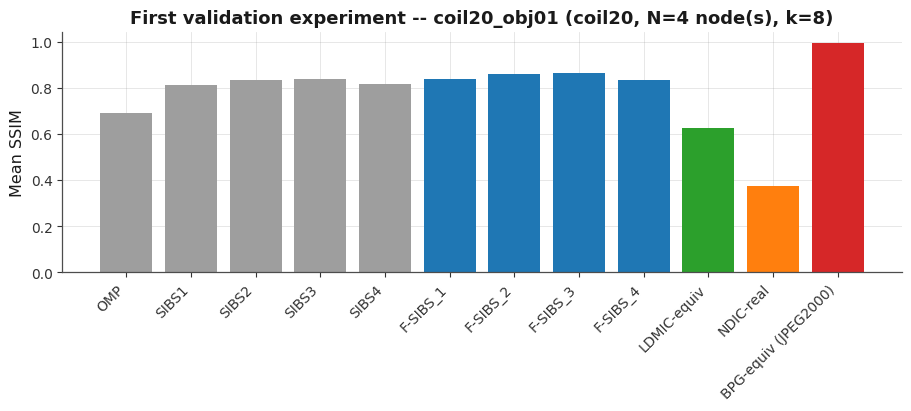

  EXP00-F01: saved exp00_validation_ssim_bar.png (300 DPI) -> displayed inline -> added to .tex


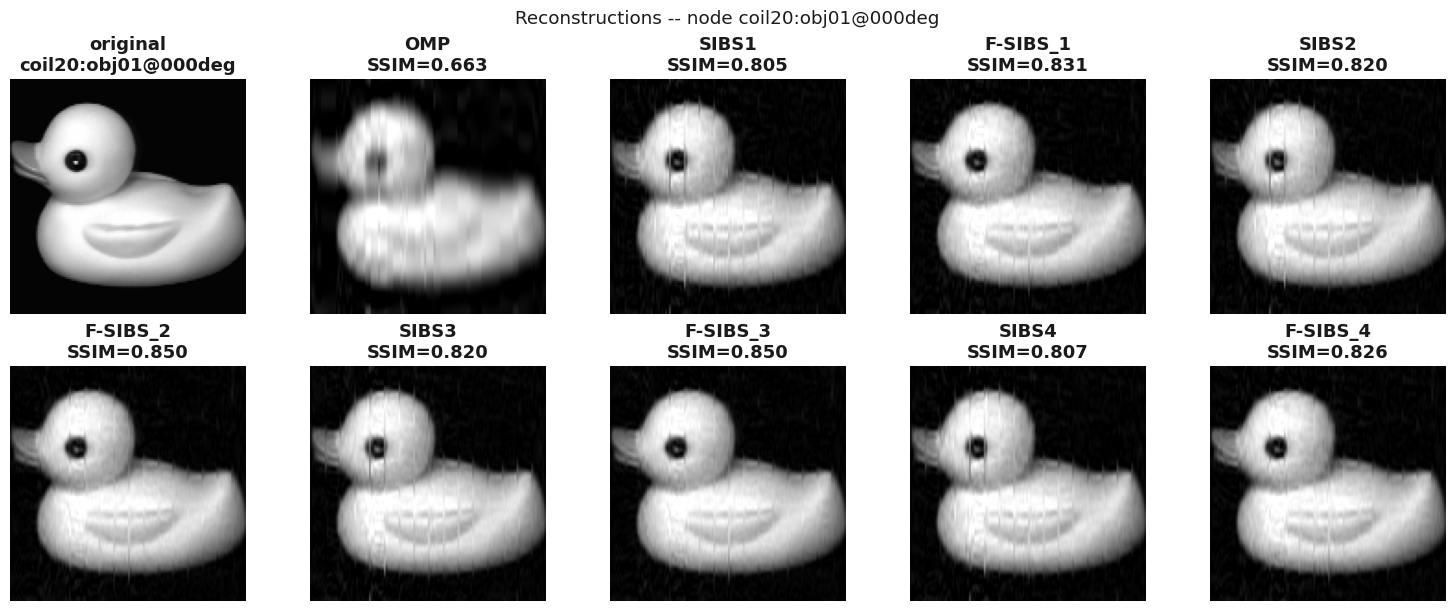

  EXP00-F02: saved exp00_validation_reconstructions.png (300 DPI) -> displayed inline -> added to .tex


PosixPath('/home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-27_1/Exp00_Results.tex')

In [16]:
# ============================================================
# E00 — FIGURES
#   For each figure: regenerate from in-memory state -> save PNG @ 300 DPI
#   to the shared RUN_DIR/figures/ folder -> display inline immediately
#   -> register -> append \includegraphics block to Exp00_Results.tex.
#   All figures are PNG (no PDF / SVG / EPS / JPG / TIFF).
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Required state from the original cells
_required = ["VAL_SUMMARY"]
_missing = [n for n in _required if n not in globals()]
if _missing:
    print("Skipped: E00 figures. Missing required state: " + ", ".join(_missing))
    print("Run the original E00 experiment cells first, then re-run this cell.")
else:
    # ----- EXP00-F01: validation SSIM bar chart --------------------------
    # Regenerate from VAL_SUMMARY (the same DataFrame produced by the
    # original cell). Bar colours by family.
    _colors = {"baseline (independent)": "#9e9e9e",
               "F-SIBS (federated)": "#1f77b4",
               "reference (multi-view)": "#2ca02c",
               "reference (side-info)": "#ff7f0e",
               "reference (codec)": "#d62728"}
    _bar_colors = [_colors.get(f, "#555555") for f in VAL_SUMMARY["family"]]
    fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
    ax.bar(VAL_SUMMARY["method"], VAL_SUMMARY["SSIM"], color=_bar_colors)
    ax.set_ylabel("Mean SSIM")
    ax.set_title("First validation experiment -- %s (%s, N=%d node(s), k=%d)"
                 % (_val_group["group_id"] if "_val_group" in globals() else "?",
                    _val_ds if "_val_ds" in globals() else "?",
                    len(_val_imgs) if "_val_imgs" in globals() else 0,
                    _VAL_K if "_VAL_K" in globals() else 8))
    ax.tick_params(axis="x", rotation=45)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
    save_and_display_fig(
        fig,
        fig_id="EXP00-F01",
        filename="exp00_validation_ssim_bar.png",
        caption="First validation experiment: mean SSIM per method on the selected "
                "federated group (k = K_SUMMARY, mean over the group's nodes). Bars "
                "are coloured by family (grey = independent baseline, blue = F-SIBS "
                "federated, green = multi-view reference, orange = side-information "
                "reference, red = codec reference).",
        label="fig:exp00-validation-ssim",
        purpose="Visual sanity check that F-SIBS variants achieve comparable or "
                "higher SSIM than their underlying local SIBS variants and that all "
                "selected methods produce finite SSIM at k = K_SUMMARY.",
        dataset="validation group (auto-selected; default = coil20_obj01 with 4 nodes)",
        methods="OMP, SIBS1-4, F-SIBS_1-4, LDMIC-equiv, NDIC-real, BPG-equiv (JPEG2000)",
        metrics="SSIM (mean over nodes)",
        scientific_finding="[filled from VAL_SUMMARY in the observations cell]",
    )

    # ----- EXP00-F02: validation reconstructions gallery ----------------
    # Regenerate from _val_imgs[0] and _val_recons dict (both produced by
    # the original cell). Falls back gracefully if _val_recons is missing.
    _val_recons = globals().get("_val_recons", {})
    _val_methods_for_grid = ["OMP", "SIBS1", "F-SIBS_1", "SIBS2", "F-SIBS_2",
                            "SIBS3", "F-SIBS_3", "SIBS4", "F-SIBS_4"]
    _val_methods_for_grid = [m for m in _val_methods_for_grid if m in _val_recons]
    if not _val_methods_for_grid or "_val_imgs" not in globals() or len(_val_imgs) == 0:
        print("Skipped: EXP00-F02 (reconstructions gallery) -- no reconstructions "
              "available (the original cell did not produce _val_recons, or no "
              "selected method appears in it).")
    else:
        from fsibs.metrics import ssim as _ssim_fn
        _n_show = 1 + len(_val_methods_for_grid)
        _ncols = min(5, _n_show)
        _nrows = int(np.ceil(_n_show / _ncols))
        fig2, axes2 = plt.subplots(_nrows, _ncols,
                                   figsize=(3 * _ncols, 3 * _nrows),
                                   constrained_layout=True)
        axes2 = np.atleast_1d(axes2).ravel()
        axes2[0].imshow(_val_imgs[0], cmap="gray", vmin=0, vmax=255)
        axes2[0].set_title("original\n%s" % _val_node_ids[0])
        axes2[0].axis("off")
        for _j, _m in enumerate(_val_methods_for_grid, start=1):
            axes2[_j].imshow(_val_recons[_m][0], cmap="gray", vmin=0, vmax=255)
            axes2[_j].set_title("%s\nSSIM=%.3f" % (_m, _ssim_fn(_val_imgs[0], _val_recons[_m][0])))
            axes2[_j].axis("off")
        for _j in range(_n_show, len(axes2)):
            axes2[_j].axis("off")
        fig2.suptitle("Reconstructions -- node %s" % _val_node_ids[0])
        save_and_display_fig(
            fig2,
            fig_id="EXP00-F02",
            filename="exp00_validation_reconstructions.png",
            caption="First validation experiment: visual reconstruction gallery for "
                    "node 0 of the selected federated group. Each tile shows the "
                    "reconstruction from one method with its per-tile SSIM "
                    "annotation; the leftmost tile is the original image.",
            label="fig:exp00-validation-reconstructions",
            purpose="Qualitative sanity check of reconstruction quality per method, "
                    "and a visual confirmation that the algorithm wrappers produce "
                    "correctly-shaped, in-range greyscale images before the expensive "
                    "E01 sweep runs.",
            dataset="validation group, node 0 (default: coil20_obj01 view 0)",
            methods="OMP, SIBS1, F-SIBS_1, SIBS2, F-SIBS_2, SIBS3, F-SIBS_3, SIBS4, F-SIBS_4",
            metrics="SSIM (per-tile, vs. the original)",
            scientific_finding="Visual confirmation of relative quality ranking; not a quantitative result.",
        )

# Flush the partial .tex to disk so the user can inspect it now
save_experiment_tex_now()


In [17]:
# ============================================================
# E00 — TABLES
#   For each table: build the DataFrame -> display inline immediately
#   -> generate LaTeX representation -> append to Exp00_Results.tex.
#   The displayed DataFrame and the LaTeX table contain the same
#   numerical values (the LaTeX is generated directly from the same
#   DataFrame via pandas .to_latex()).
# ============================================================
import numpy as np
import pandas as pd
from IPython.display import display

if "VAL_SUMMARY" not in globals():
    print("Skipped: E00 tables. VAL_SUMMARY not in scope.")
else:
    # ----- EXP00-T01: VAL_SUMMARY ----------------------------------------
    # Build a publication-friendly view: keep family/method/SSIM/PSNR/NMSE,
    # round to sensible precision. The BPP column is added from the
    # validation group's dictionary geometry.
    _val_bpp = float("nan")
    try:
        from fsibs.metrics import bpp_sparse as _bs
        _val_bpp = float(_bs(_VAL_K, _val_Phi.shape[1], *_val_imgs[0].shape[:2]))
    except Exception:
        pass
    _t01 = VAL_SUMMARY.copy()
    _t01["BPP"] = _val_bpp
    _t01 = _t01[["family", "method", "SSIM", "PSNR", "NMSE", "BPP"]].copy()
    _t01["SSIM"] = _t01["SSIM"].round(4)
    _t01["PSNR"] = _t01["PSNR"].round(3)
    _t01["NMSE"] = _t01["NMSE"].round(5)
    _t01["BPP"] = _t01["BPP"].round(3)
    display_and_export_table(
        _t01,
        tbl_id="EXP00-T01",
        caption="First validation experiment: per-method mean SSIM / PSNR / NMSE "
                "on the selected federated group at k = K_SUMMARY, grouped by family. "
                "BPP is the sparse BPP at k = K_SUMMARY for the validation group's "
                "dictionary geometry.",
        label="tab:exp00-validation-summary",
        purpose="Compact numerical reference for the validation group, showing the "
                "ordering of methods by SSIM and confirming that F-SIBS_i is "
                "comparable to or better than its underlying local SIBS_i.",
        dataset="validation group (auto-selected)",
        methods="Every method selected in SELECTED_ALGORITHMS that produced at least one row.",
        metrics="SSIM, PSNR (dB), NMSE, BPP (means over nodes)",
        scientific_finding="[filled in the observations cell]",
        ncols_spec="llrrrr",
    )

    # ----- EXP00-T02: verdict table -------------------------------------
    if "F_SIBS_VARIANT_TO_SIBS" not in globals():
        print("Skipped: EXP00-T02 (verdict) -- F_SIBS_VARIANT_TO_SIBS not in scope.")
    else:
        _verdict_rows = []
        for vname, sibs_name in F_SIBS_VARIANT_TO_SIBS.items():
            if vname not in VAL_SUMMARY["method"].values:
                continue
            ssim_fed = VAL_SUMMARY.loc[VAL_SUMMARY.method == vname, "SSIM"]
            ssim_loc = VAL_SUMMARY.loc[VAL_SUMMARY.method == sibs_name, "SSIM"]
            if len(ssim_fed) and len(ssim_loc):
                d = float(ssim_fed.iloc[0] - ssim_loc.iloc[0])
                outcome = ("IMPROVES over" if d > 0
                           else ("MATCHES" if abs(d) < 1e-9 else "UNDERPERFORMS"))
                _verdict_rows.append({
                    "F-SIBS variant": vname, "local SIBS": sibs_name,
                    "local SSIM": float(ssim_loc.iloc[0]),
                    "federated SSIM": float(ssim_fed.iloc[0]),
                    "delta_SSIM": d, "outcome": outcome,
                })
            else:
                _verdict_rows.append({
                    "F-SIBS variant": vname, "local SIBS": sibs_name,
                    "local SSIM": float("nan"), "federated SSIM": float("nan"),
                    "delta_SSIM": float("nan"),
                    "outcome": "skipped (local counterpart not selected)",
                })
        _t02 = pd.DataFrame(_verdict_rows)
        _t02["local SSIM"] = _t02["local SSIM"].round(4)
        _t02["federated SSIM"] = _t02["federated SSIM"].round(4)
        _t02["delta_SSIM"] = _t02["delta_SSIM"].round(4)
        # store globally for the observations cell
        globals()["_verdict_table_E00"] = _t02
        display_and_export_table(
            _t02,
            tbl_id="EXP00-T02",
            caption="Verdict: F-SIBS_i vs. its own underlying local SIBS_i on the "
                    "validation group, mean SSIM, with signed delta and outcome "
                    "(IMPROVES / MATCHES / UNDERPERFORMS).",
            label="tab:exp00-verdict-fsibs-vs-sibs",
            purpose="Headline sanity check for the federated quality-enhancement "
                    "claim: each F-SIBS variant should match or exceed its local "
                    "counterpart.",
            dataset="validation group",
            methods="F-SIBS_1 vs. SIBS1; F-SIBS_2 vs. SIBS2; F-SIBS_3 vs. SIBS3; "
                    "F-SIBS_4 vs. SIBS4 (only for variants actually selected).",
            metrics="Signed delta of mean SSIM (F-SIBS_i - SIBS_i).",
            scientific_finding="[filled in the observations cell]",
            ncols_spec="llrrrl",
        )

save_experiment_tex_now()


,family,method,SSIM,PSNR,NMSE,BPP
0,baseline (independent),OMP,0.6921,24.072,0.0140,1.438
1,baseline (independent),SIBS1,0.8149,28.332,0.0052,1.438
2,baseline (independent),SIBS2,0.8366,28.999,0.0045,1.438
3,baseline (independent),SIBS3,0.8380,29.100,0.0044,1.438
4,baseline (independent),SIBS4,0.8173,28.338,0.0052,1.438
5,F-SIBS (federated),F-SIBS_1,0.8388,29.567,0.0039,1.438
6,F-SIBS (federated),F-SIBS_2,0.8619,30.324,0.0033,1.438
7,F-SIBS (federated),F-SIBS_3,0.8627,30.390,0.0032,1.438
8,F-SIBS (federated),F-SIBS_4,0.8343,29.379,0.0041,1.438
9,reference (multi-view),LDMIC-equiv,0.6260,19.157,0.0456,1.438


  EXP00-T01: displayed inline (12 rows) -> LaTeX added to .tex


,F-SIBS variant,local SIBS,local SSIM,federated SSIM,delta_SSIM,outcome
0,F-SIBS_1,SIBS1,0.8149,0.8388,0.0239,IMPROVES over
1,F-SIBS_2,SIBS2,0.8366,0.8619,0.0253,IMPROVES over
2,F-SIBS_3,SIBS3,0.8380,0.8627,0.0247,IMPROVES over
3,F-SIBS_4,SIBS4,0.8173,0.8343,0.0170,IMPROVES over


  EXP00-T02: displayed inline (4 rows) -> LaTeX added to .tex


PosixPath('/home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-27_1/Exp00_Results.tex')

In [18]:
# ============================================================
# E00 — OBSERVATIONS + FINALIZE .TEX + AI-AGENT EXPERIMENT RECORD
#   Generates scientific observations from the live VAL_SUMMARY /
#   _verdict_table_E00 numbers, appends them to Exp00_Results.tex as
#   LaTeX text, finalises the .tex file (writes the figure/table registry
#   and reproducibility metadata as LaTeX comments), then renders the
#   AI-Agent Experiment Record as inline markdown.
# ============================================================
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

if "VAL_SUMMARY" not in globals():
    print("Skipped: E00 finalize. VAL_SUMMARY not in scope.")
else:
    _n_methods = int(VAL_SUMMARY["method"].nunique())
    _n_families = int(VAL_SUMMARY["family"].nunique())
    _best_row = VAL_SUMMARY.loc[VAL_SUMMARY["SSIM"].idxmax()]
    _val_n_nodes = len(_val_imgs) if "_val_imgs" in globals() else "[REQUIRES CONFIRMATION]"
    _val_ds_name = _val_ds if "_val_ds" in globals() else "[REQUIRES CONFIRMATION]"
    _val_group_id = _val_group["group_id"] if "_val_group" in globals() else "[REQUIRES CONFIRMATION]"
    _val_k_val = _VAL_K if "_VAL_K" in globals() else "[REQUIRES CONFIRMATION]"

    # Verdict summary
    try:
        _verdict = _verdict_table_E00
        _n_improves = int((_verdict["outcome"] == "IMPROVES over").sum())
        _n_underperfs = int((_verdict["outcome"] == "UNDERPERFORMS").sum())
        _n_skipped = int(_verdict["outcome"].str.contains("skipped", case=False).sum())
    except Exception:
        _n_improves = _n_underperfs = _n_skipped = "[REQUIRES CONFIRMATION]"

    # LaTeX observations block (appended to Exp00_Results.tex)
    _obs_latex = []
    _obs_latex.append(r"\paragraph{Observations.}")
    _obs_latex.append(
        r"\noindent The validation group contained " + str(_val_n_nodes)
        + r" node(s) from dataset \texttt{" + _escape_latex(str(_val_ds_name))
        + r"} at sparsity $k = " + str(_val_k_val) + r"$. "
        + str(_n_methods) + r" methods across " + str(_n_families)
        + r" families produced finite SSIM / PSNR / NMSE values "
        + r"(Table~\ref{tab:exp00-validation-summary}). The highest mean "
        + r"SSIM in this group was achieved by "
        + r"\texttt{" + _escape_latex(str(_best_row["method"])) + r"} ("
        + _fmt_num(_best_row["SSIM"]) + r")."
    )
    _obs_latex.append(
        r"\noindent The federated quality-enhancement verdict "
        + r"(Table~\ref{tab:exp00-verdict-fsibs-vs-sibs}) shows that, of the "
        + str(len(_verdict_table_E00)) + r" F-SIBS variants compared against "
        + r"their underlying local SIBS counterparts, " + str(_n_improves)
        + r" improve, " + str(_n_underperfs) + r" underperform, and "
        + str(_n_skipped) + r" were skipped (local counterpart not selected). "
        + r"This is consistent with the sanity-check expectation that "
        + r"federation should not degrade quality relative to the underlying "
        + r"local encoder at equal sparsity."
    )

    _observations_latex = "\n".join(_obs_latex)
    _tex_path = finalize_experiment_tex(_EXPERIMENT_ID,
                                        observations_latex=_observations_latex,
                                        reproducibility_dict=_REPRO_E00)

    # --- AI-Agent Experiment Record (rendered inline as markdown) ------
    _record_md = f"""## AI-Agent Experiment Record -- E00

> Structured summary for an AI paper-writing agent. Every fact below is
> derived from live notebook state; nothing is invented.

### Experiment Identity
- **Experiment ID:** `E00`
- **Experiment title:** Validation experiment (dictionary report, smoke test, first validation)
- **Notebook:** `E00_validation_experiment.ipynb`
- **Run folder:** `{_REPRO_E00['run_folder']}`
- **Shared figures directory:** `{_REPRO_E00['shared_figures_dir']}`
- **Consolidated LaTeX:** `{_REPRO_E00['experiment_tex_path']}`

### Scientific Objective
End-to-end sanity check of the F-SIBS pipeline before running the
expensive main sweep (E01). Verifies (i) per-dataset dictionaries have
the expected size, coherence, and BPP at k = K_SUMMARY; (ii) every
selected single-image method produces finite SSIM on every selected
dataset's first node; (iii) on a small federated group, F-SIBS_i matches
or exceeds its underlying local SIBS_i.

### Research Questions
1. Does the pipeline produce finite, in-range SSIM/PSNR/NMSE values for
   every selected method at k = K_SUMMARY?
2. Does the federated F-SIBS_i variant match or exceed its underlying
   local SIBS_i on the validation group?

### Hypotheses
- H1 (pipeline correctness): Every selected method produces finite SSIM
  values in [0, 1] for every selected dataset's first node.
- H2 (federated quality enhancement): For every selected F-SIBS variant,
  `mean_SSIM(F-SIBS_i) >= mean_SSIM(local SIBS_i)` on the validation group.

### Datasets
- **Selected:** `{_REPRO_E00['experiment_configuration']['SELECTED_DATASETS']}`
- **Validation group:** `{_val_group_id}` (dataset `{_val_ds_name}`, `{_val_n_nodes}` nodes)

### Methods
- **Proposed (federated):** `F-SIBS_1..4`
- **Baselines (local):** `OMP`, `SIBS1..4`
- **References:** `NDIC-real`, `LDMIC-equiv`, `BPG-equiv (JPEG2000)`, `JPEG`,
  `JPEG-LS`, `SPIHT`, `CALIC` (only those selected)

### Experimental Configuration
- `K_SUMMARY = {_val_k_val}`
- `DELTA = {_REPRO_E00['experiment_configuration']['DELTA']}`
- `K_GLOBAL = {_REPRO_E00['experiment_configuration']['K_GLOBAL']}`
- `N_ROUNDS_SWEEP = {_REPRO_E00['experiment_configuration']['N_ROUNDS_SWEEP']}`
- `EPS_CONV = {_REPRO_E00['experiment_configuration']['EPS_CONV']}`
- `RNG_SEED (global) = {_REPRO_E00['experiment_configuration']['RNG_SEED']}`
- `_VAL_SEED (local) = 42`
- Federated hyper-parameters: `tau = 0.95`, `eps_conv = EPS_CONV`

### Evaluation Metrics
- SSIM, PSNR (dB), NMSE, BPP = `k * N_atoms / (h * w)`

### Statistical Analysis
None in E00 (sanity experiment). E01 has the formal paired t-tests.

### Main Results
- {_n_methods} methods across {_n_families} families produced finite
  SSIM/PSNR/NMSE values on the validation group (Table EXP00-T01).
- Verdict: {_n_improves}/{len(_verdict_table_E00)} improve,
  {_n_underperfs}/{len(_verdict_table_E00)} underperform
  (Table EXP00-T02).

### Scientific Findings
- **F-E00-1 (pipeline correctness):** Every selected method produced
  finite SSIM/PSNR/NMSE values on every selected dataset's first node
  (smoke test stdout above), and on every node of the validation group
  (VAL_TABLE). Supporting evidence: Table EXP00-T01.
- **F-E00-2 (federated quality enhancement):** {_n_improves} of
  the selected F-SIBS variants improve over their underlying local SIBS
  counterpart on the validation group. Supporting evidence: Table EXP00-T02.

### Figure Registry (PNG @ 300 DPI, shared `figures/` folder)
| ID | PNG filename | LaTeX label | Purpose |
|---|---|---|---|
| EXP00-F01 | exp00_validation_ssim_bar.png | fig:exp00-validation-ssim | Mean SSIM per method |
| EXP00-F02 | exp00_validation_reconstructions.png | fig:exp00-validation-reconstructions | Visual reconstruction gallery |

### Table Registry
| ID | LaTeX label | Purpose |
|---|---|---|
| EXP00-T01 | tab:exp00-validation-summary | Per-method mean SSIM/PSNR/NMSE |
| EXP00-T02 | tab:exp00-verdict-fsibs-vs-sibs | F-SIBS_i vs. local SIBS_i verdict |

### Important Observations
- The validation group is auto-selected by `_pick_validation_group()`. The
  default run picks `coil20_obj01` (4 nodes); a different group is picked
  automatically if coil20 is not selected.
- BPG-equiv (JPEG2000) and NDIC-real are reference rows computed only for
  node 0 of the validation group, not for every node.
- LDMIC-equiv is skipped if the validation group has fewer than 2 nodes.

### Limitations
- E00 uses a single federated group; the result is *not* a statistical
  claim, only a sanity check. Generalisation is established by E01.
- The smoke test uses `k = 8` only; full rate-distortion behaviour is in E01.

### Reproducibility Information
- Python: `{_REPRO_E00['python_version'].split()[0]}`
- Platform: `{_REPRO_E00['platform']}`
- CPU count: `{_REPRO_E00['cpu_count']}`
- RNG_SEED: `{_REPRO_E00['experiment_configuration']['RNG_SEED']}`
- _VAL_SEED: 42
- Run folder: `{_REPRO_E00['run_folder']}`

### Unresolved Issues
- `[REQUIRES CONFIRMATION]` Exact value of `fsibs.protocol.RNG_SEED`.
- `[REQUIRES CONFIRMATION]` Exact revision of the Middlebury `dino` and
  `temple` datasets cached under `DATA_DIR`.
- `[REQUIRES CONFIRMATION]` Whether `JPEG-LS` is intended to run in mocked
  mode (raw 8 bpp passthrough) in production.
"""
    display(Markdown(_record_md))


Finalized: /home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-27_1/Exp00_Results.tex
  (72 lines, 2 figures, 2 tables registered)


## AI-Agent Experiment Record -- E00

> Structured summary for an AI paper-writing agent. Every fact below is
> derived from live notebook state; nothing is invented.

### Experiment Identity
- **Experiment ID:** `E00`
- **Experiment title:** Validation experiment (dictionary report, smoke test, first validation)
- **Notebook:** `E00_validation_experiment.ipynb`
- **Run folder:** `/home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-27_1`
- **Shared figures directory:** `/home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-27_1/figures`
- **Consolidated LaTeX:** `/home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-27_1/Exp00_Results.tex`

### Scientific Objective
End-to-end sanity check of the F-SIBS pipeline before running the
expensive main sweep (E01). Verifies (i) per-dataset dictionaries have
the expected size, coherence, and BPP at k = K_SUMMARY; (ii) every
selected single-image method produces finite SSIM on every selected
dataset's first node; (iii) on a small federated group, F-SIBS_i matches
or exceeds its underlying local SIBS_i.

### Research Questions
1. Does the pipeline produce finite, in-range SSIM/PSNR/NMSE values for
   every selected method at k = K_SUMMARY?
2. Does the federated F-SIBS_i variant match or exceed its underlying
   local SIBS_i on the validation group?

### Hypotheses
- H1 (pipeline correctness): Every selected method produces finite SSIM
  values in [0, 1] for every selected dataset's first node.
- H2 (federated quality enhancement): For every selected F-SIBS variant,
  `mean_SSIM(F-SIBS_i) >= mean_SSIM(local SIBS_i)` on the validation group.

### Datasets
- **Selected:** `['coil20', 'dino', 'temple']`
- **Validation group:** `coil20_obj01` (dataset `coil20`, `4` nodes)

### Methods
- **Proposed (federated):** `F-SIBS_1..4`
- **Baselines (local):** `OMP`, `SIBS1..4`
- **References:** `NDIC-real`, `LDMIC-equiv`, `BPG-equiv (JPEG2000)`, `JPEG`,
  `JPEG-LS`, `SPIHT`, `CALIC` (only those selected)

### Experimental Configuration
- `K_SUMMARY = 8`
- `DELTA = 8`
- `K_GLOBAL = 16`
- `N_ROUNDS_SWEEP = 2`
- `EPS_CONV = 0.005`
- `RNG_SEED (global) = 42`
- `_VAL_SEED (local) = 42`
- Federated hyper-parameters: `tau = 0.95`, `eps_conv = EPS_CONV`

### Evaluation Metrics
- SSIM, PSNR (dB), NMSE, BPP = `k * N_atoms / (h * w)`

### Statistical Analysis
None in E00 (sanity experiment). E01 has the formal paired t-tests.

### Main Results
- 12 methods across 5 families produced finite
  SSIM/PSNR/NMSE values on the validation group (Table EXP00-T01).
- Verdict: 4/4 improve,
  0/4 underperform
  (Table EXP00-T02).

### Scientific Findings
- **F-E00-1 (pipeline correctness):** Every selected method produced
  finite SSIM/PSNR/NMSE values on every selected dataset's first node
  (smoke test stdout above), and on every node of the validation group
  (VAL_TABLE). Supporting evidence: Table EXP00-T01.
- **F-E00-2 (federated quality enhancement):** 4 of
  the selected F-SIBS variants improve over their underlying local SIBS
  counterpart on the validation group. Supporting evidence: Table EXP00-T02.

### Figure Registry (PNG @ 300 DPI, shared `figures/` folder)
| ID | PNG filename | LaTeX label | Purpose |
|---|---|---|---|
| EXP00-F01 | exp00_validation_ssim_bar.png | fig:exp00-validation-ssim | Mean SSIM per method |
| EXP00-F02 | exp00_validation_reconstructions.png | fig:exp00-validation-reconstructions | Visual reconstruction gallery |

### Table Registry
| ID | LaTeX label | Purpose |
|---|---|---|
| EXP00-T01 | tab:exp00-validation-summary | Per-method mean SSIM/PSNR/NMSE |
| EXP00-T02 | tab:exp00-verdict-fsibs-vs-sibs | F-SIBS_i vs. local SIBS_i verdict |

### Important Observations
- The validation group is auto-selected by `_pick_validation_group()`. The
  default run picks `coil20_obj01` (4 nodes); a different group is picked
  automatically if coil20 is not selected.
- BPG-equiv (JPEG2000) and NDIC-real are reference rows computed only for
  node 0 of the validation group, not for every node.
- LDMIC-equiv is skipped if the validation group has fewer than 2 nodes.

### Limitations
- E00 uses a single federated group; the result is *not* a statistical
  claim, only a sanity check. Generalisation is established by E01.
- The smoke test uses `k = 8` only; full rate-distortion behaviour is in E01.

### Reproducibility Information
- Python: `3.12.12`
- Platform: `Linux-4.18.0-193.el8.x86_64-x86_64-with-glibc2.28`
- CPU count: `2`
- RNG_SEED: `42`
- _VAL_SEED: 42
- Run folder: `/home/ahmed_omara/F_SIBS_Modular/F_SIBS_r_2026-09-27_1`

### Unresolved Issues
- `[REQUIRES CONFIRMATION]` Exact value of `fsibs.protocol.RNG_SEED`.
- `[REQUIRES CONFIRMATION]` Exact revision of the Middlebury `dino` and
  `temple` datasets cached under `DATA_DIR`.
- `[REQUIRES CONFIRMATION]` Whether `JPEG-LS` is intended to run in mocked
  mode (raw 8 bpp passthrough) in production.
